# Does chasing provide an advantage in T20 cricket?

In T20 cricket, teams can either bat first or chase a target. There is a common belief that chasing provides an advantage, as teams know the target they need to reach.
This project uses Indian Premier League (IPL) match data to investigate whether chasing teams win more often, and whether this advantage is statistically significant.

The dataset used contains match data from the IPL from 2008-2024, including teams involved, toss decisions and match outcomes.

## Loadng the data
We begin by importing the necessary Python libraries for data analysis and visualisation. The IPL match dataset is then loaded into a dataframe, allowing us to explore its structure and contents.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

df = pd.read_csv("matches.csv")

To analyse whether chasing provides an advantage, we first identify which team batted second in each match. This is determined using the toss decision.
We then create a variable called 'chasing_win', which takes the value 1 if the chasing team won the match, and 0 otherwise. This allows us to compare outcomes between teams batting first and second.

In [27]:
df['chasing_team'] = np.where(
    df['toss_decision'] == 'field',
    df['toss_winner'],
    np.where(
        df['toss_winner'] == df['team1'],
        df['team2'],
        df['team1']
    )
)

df['chasing_win'] = np.where(df['winner'] == df['chasing_team'], 1, 0)


## Comparing Win Rates
We calculate the proportion of matches won by teams that were chasing. This provides a simple measure of whether batting second is associated with a higher probability of winning.

In [24]:
win_rate = df['chasing_win'].mean()

print("Chasing win rate:", win_rate)
print("Batting first win rate:", 1 - win_rate)

Chasing win rate: 0.5388127853881278
Batting first win rate: 0.4611872146118722


The following chart compares the win rates of teams batting first and those chasing. This provides a clear visual respresenation of any advantage associated with batting second.

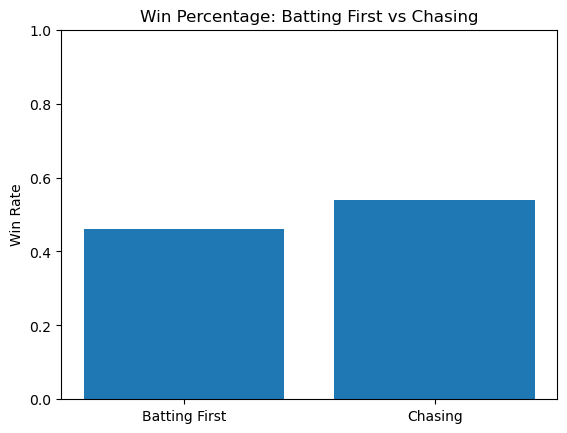

In [12]:
labels = ['Batting First', 'Chasing']
values = [1 - win_rate, win_rate]

plt.bar(labels, values)
plt.title("Win Percentage: Batting First vs Chasing")
plt.ylabel("Win Rate")
plt.ylim(0, 1)
plt.show()

The figure shows that teams batting second (chasing) win approximately 53.8% of matches, compared to 46.2% for teams batting first. This indicates that chasing teams win more frequently, suggesting that batting second is associated with a higher probability of winning in T20 cricket.

## Toss Analysis
The toss plays an important role in T20 cricket, as it allows the winning team to choose whether to bat or field. This decision can influence whether a team ends up chasing, and therefore affect match outcomes.
We first examine whether winning the toss is associated with a higher probability of winning the match

Win rate when winning toss: 0.5059360730593607
Win rate when losing toss: 0.4940639269406393


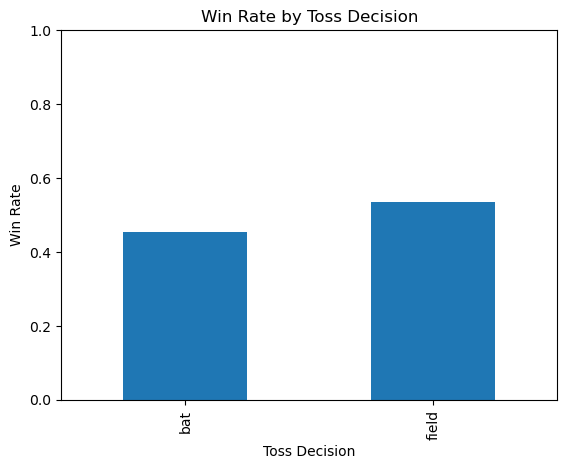

In [21]:
df['toss_win_match'] = np.where(df['winner'] == df['toss_winner'], 1, 0)

toss_win_rate = df['toss_win_match'].mean()

print("Win rate when winning toss:", toss_win_rate)
print("Win rate when losing toss:", 1 - toss_win_rate)

toss_decision_win = df.groupby('toss_decision')['toss_win_match'].mean()

toss_decision_win.plot(kind='bar')

plt.title("Win Rate by Toss Decision")
plt.ylabel("Win Rate")
plt.xlabel("Toss Decision")
plt.ylim(0, 1)
plt.show()

The results show that teams winning the toss have a win rate of approximately 50.6%, which is only slightly above 50%. This suggests that winning the toss does not provide a strong advantage in terms of match outcomes.
While the toss allows teams to choose whether to bat or field, its direct impact on winning seems to be limited. This indicates other factors, such as match conditions and team performance, are likely more important in determining the outcome.

## Toss Decisions
We now examine what teams choose to do after winning the toss. In particular, we are interested in whether teams prefer to field, which indicate a preference for chasing.

In [13]:
toss_decisions = df['toss_decision'].value_counts(normalize=True)

print(f"Field first: {toss_decisions['field']:.3f}")
print(f"Bat first: {toss_decisions['bat']:.3f}")

Field first: 0.643
Bat first: 0.357


The results show that approximately 64.3% of teams choose to field after winning the toss, compared to 35.7% choosing to bat. This indicates a clear preference for fielding first, suggesting that teams often opt to chase rather than set a target.

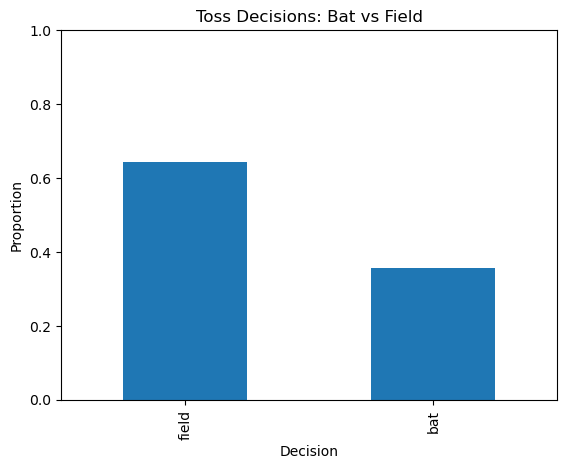

In [15]:
toss_decisions.plot(kind='bar')

plt.title("Toss Decisions: Bat vs Field")
plt.ylabel("Proportion")
plt.xlabel("Decision")
plt.ylim(0, 1)
plt.show()

The chart shows how frequently teams choose to bat or field after winning the toss. A higher proportion of teams choosing to field suggests that captains often prefer to chase, which may indicate a perceived advantage in batting second.

## Regression Analysis
To further examine the impact of chasing on match outcomes, we use a logistic regression model. The dependent variable is whether team1 won the match, while the independent variable indicates whether team1 was the chasing team.
This allows us to test whether being the chasing team is associated with a higher probability of winning.

In [22]:
df['team1_win'] = (df['winner'] == df['team1']).astype(int)
df['team1_chasing'] = (df['chasing_team'] == df['team1']).astype(int)

X = df[['team1_chasing']]
X = sm.add_constant(X)

y = df['team1_win']

model = sm.Logit(y, X).fit(disp=0)

print("Regression coefficient:", round(model.params['team1_chasing'], 3))
print("P-value:", round(model.pvalues['team1_chasing'], 3))
print("Pseudo R-squared:", round(model.prsquared, 3))

Regression coefficient: 0.462
P-value: 0.001
Pseudo R-squared: 0.008


The logistic regression results suggest that being the chasing team is positively associated with winning. The coefficient for team1_chasing is 0.4622, indicating that teams batting second are more likely to win compared to teams batting first.
The p-value for this variable is 0.001, which is statistically significant at conventional levels. This suggests that the relationship between chasing and winning is unlikely to be due to random chance.
The constant term is not statistically significant (p = 0.167), indicating that the baseline probability of winning when not chasing is not significantly different from zero in this specification.
Overall, the results support the earlier descriptive findings, providing evidence that chasing is associated with a higher probability of winning in T20 cricket. However, this should be interpreted as an association rather than a causal relationship, as other factors such as team strength and match conditions may also influence the outcome

## Proportion of Matches Won by Chasing Teams by Season

We examine how the proportion of matches won by chasing teams varies across seasons. This provides further insight into whether the advantage of chasing is consistent over time.

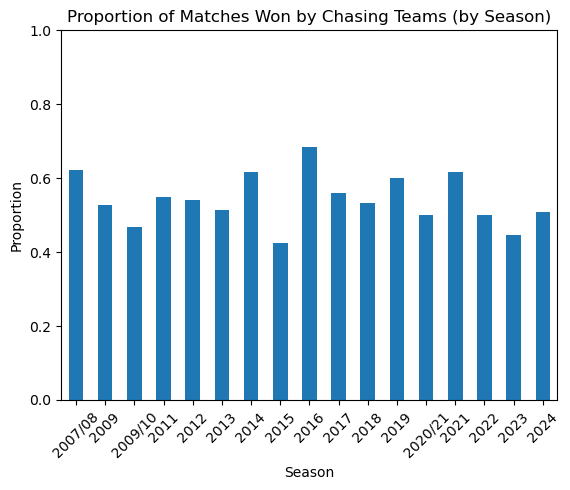

In [18]:
# total matches per season
matches_per_season = df.groupby('season').size()

# total chasing wins per season
chasing_wins_per_season = df.groupby('season')['chasing_win'].sum()

# proportion
chasing_win_prop = chasing_wins_per_season / matches_per_season

chasing_win_prop.plot(kind='bar')

plt.title("Proportion of Matches Won by Chasing Teams (by Season)")
plt.ylabel("Proportion")
plt.xlabel("Season")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.show()

The chart shows the proportion of matches won by chasing teams across seasons. While there are fluctuations, the proportion generally remains around or above 50%, suggesting that the advantage of chasing is relatively stable over time.

## Chasing Advantage by Venue

We examine how the success of chasing varies across different venues. This helps assess whether the advantage of chasing depends on playing conditions such as pitch or location.

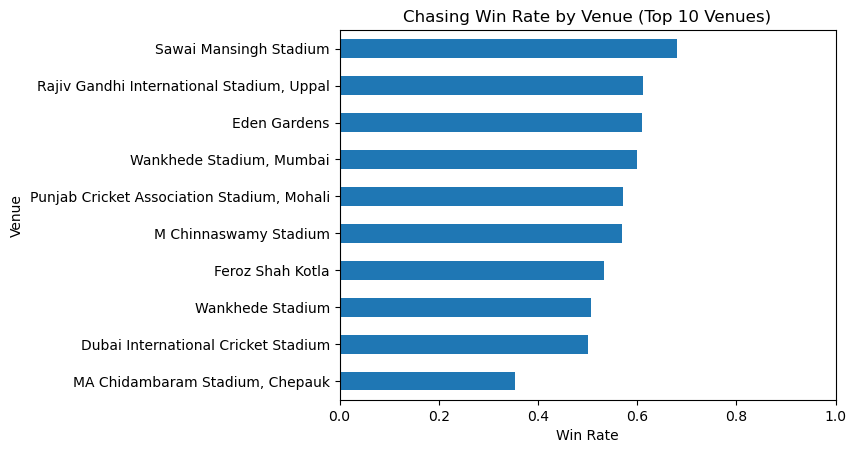

In [19]:
# get top 10 venues by number of matches
top_venues = df['venue'].value_counts().head(10).index

venue_data = df[df['venue'].isin(top_venues)]

venue_chasing = venue_data.groupby('venue')['chasing_win'].mean().sort_values()

venue_chasing.plot(kind='barh')

plt.title("Chasing Win Rate by Venue (Top 10 Venues)")
plt.xlabel("Win Rate")
plt.ylabel("Venue")
plt.xlim(0, 1)
plt.show()

The chart shows that the success of chasing varies across venues. This suggests that local conditions, such as pitch characteristics and ground size, may influence match outcomes.
While chasing appears to provide an advantage overall, its effectiveness is not consistent across all venues, indicating that context plays an important role.

## Conclusion

This project investigated whether chasing provides an advantage in T20 cricket using IPL match data.

The analysis shows that teams batting second win a higher proportion of matches (approximately 53.8%) compared to teams batting first (46.2%), suggesting that chasing is associated with a higher likelihood of winning.

The toss analysis revealed that winning the toss does not significantly increase the probability of winning, but teams overwhelmingly choose to field after winning the toss. This indicates a strong preference for chasing, suggesting that teams believe it provides a strategic advantage.

The regression analysis further supports this finding, showing that being the chasing team is positively and significantly associated with winning.

However, the venue analysis demonstrates that this advantage is not consistent across all conditions, indicating that factors such as pitch characteristics and playing environment also influence outcomes.

A limitation of this analysis is that it does not control for factors such as team strength, player performance, or match conditions, which may also influence match outcomes.

Overall, the results suggest that chasing appears to provide a small advantage in T20 cricket, although it is not the only factor determining match results.